Loading data and model...
Average expected cost (model policy): 5,444.97
Average expected cost (baseline always-B): 4,300.00
Estimated savings per patient: -1,144.97
Estimated savings per 1000 patients: -1,144,969.64


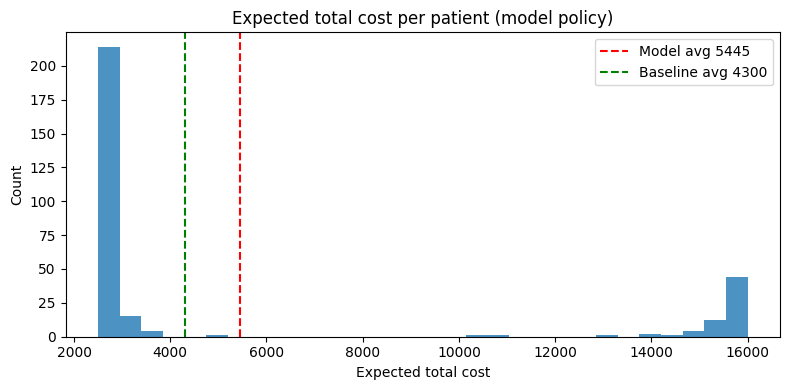

Saved results to reports/: model_costs_per_patient.csv, cost_summary.csv, cost_distribution.png


In [1]:
# STEP 6: Cost-effectiveness analysis (single cell)
import os, joblib, pandas as pd, numpy as np
import matplotlib.pyplot as plt

ROOT = r'C:\Users\mdsha\super-duper-funicular'
DATA_PATH = os.path.join(ROOT, 'data', 'health_data_cleaned.csv')
MODEL_PATH = os.path.join(ROOT, 'models', 'final_model.pkl')
REPORTS_DIR = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

# Synthetic cost params — edit if you want different numbers
TREATMENT_COST = {'A': 2500.0, 'B': 1000.0}   # per-patient cost of treatment
HOSP_COST = 15000.0                           # cost if patient has bad outcome (hospitalization)

# load
print("Loading data and model...")
df = pd.read_csv(DATA_PATH)
model = joblib.load(MODEL_PATH)

# ensure engineered features exist (defensive)
if 'bmi' not in df.columns:
    df['bmi'] = df['weight'] / ((df['height']/100)**2)
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,150], labels=['<30','30-45','45-60','60+'])
if 'smoker_comorb' not in df.columns:
    df['smoker_comorb'] = df['smoker'] * df['comorbidity_score']
if 'risk_score' not in df.columns:
    df['risk_score'] = (df['systolic']/180 + df['cholesterol']/300 + df['comorbidity_score']/5 + (1 - df['exercise_level']/5))

# prepare features & probabilities
X = df.drop(columns=['outcome'])
probs = model.predict_proba(X)[:,1]   # probability of positive outcome

# policy: model-based (if prob >= threshold -> A else B)
threshold = 0.5
recommended = np.where(probs >= threshold, 'A', 'B')
treatment_cost_arr = np.array([TREATMENT_COST[t] for t in recommended])

# expected hospital cost per patient = (1 - prob_positive) * HOSP_COST
exp_hosp_cost = (1 - probs) * HOSP_COST

# total expected cost per patient under model policy
expected_total = treatment_cost_arr + exp_hosp_cost

# baseline policy: always B
baseline_treatment_cost = TREATMENT_COST['B']
baseline_expected_cost_per_patient = baseline_treatment_cost + (1 - df['outcome'].mean()) * HOSP_COST

# aggregate
results = pd.DataFrame({
    'patient_index': df.index,
    'prob_positive': probs,
    'recommended_treatment': recommended,
    'treatment_cost': treatment_cost_arr,
    'expected_hosp_cost': exp_hosp_cost,
    'expected_total_cost': expected_total,
    'actual_outcome': df['outcome']
})

# summary numbers
avg_model_cost = expected_total.mean()
avg_baseline_cost = baseline_expected_cost_per_patient
savings_per_patient = avg_baseline_cost - avg_model_cost
savings_per_1000 = savings_per_patient * 1000

print(f"Average expected cost (model policy): {avg_model_cost:,.2f}")
print(f"Average expected cost (baseline always-B): {avg_baseline_cost:,.2f}")
print(f"Estimated savings per patient: {savings_per_patient:,.2f}")
print(f"Estimated savings per 1000 patients: {savings_per_1000:,.2f}")

# save per-patient CSV and aggregated summary + plot
results.to_csv(os.path.join(REPORTS_DIR, 'model_costs_per_patient.csv'), index=False)
summary = {
    'avg_model_cost': avg_model_cost,
    'avg_baseline_cost': avg_baseline_cost,
    'savings_per_patient': savings_per_patient,
    'savings_per_1000': savings_per_1000,
    'threshold': threshold
}
pd.Series(summary).to_csv(os.path.join(REPORTS_DIR, 'cost_summary.csv'))

# plot distribution and vertical lines
plt.figure(figsize=(8,4))
plt.hist(expected_total, bins=30, alpha=0.8)
plt.axvline(avg_model_cost, color='red', linestyle='--', label=f'Model avg {avg_model_cost:.0f}')
plt.axvline(avg_baseline_cost, color='green', linestyle='--', label=f'Baseline avg {avg_baseline_cost:.0f}')
plt.legend()
plt.title('Expected total cost per patient (model policy)')
plt.xlabel('Expected total cost')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'cost_distribution.png'), dpi=200)
plt.show()

print("Saved results to reports/: model_costs_per_patient.csv, cost_summary.csv, cost_distribution.png")
